![image-2.png](attachment:image-2.png)
_Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Análisis de reducción de dimensionalidad: PCA y t-SNE
## Objetivo General
En este trabajo, se busca que pongas en práctica la aplicación de algoritmos de reducción de dimensionalidad. El objetivo es aplicar técnicas para reducir la dimensionalidad a 2D, graficar los resultados y seleccionar la mejor técnica para los datos. Además, deberás detallar los pasos a seguir para la reducción de dimensionalidad y analizar los resultados obtenidos.

### Objetivos específicos 
* Entender los métodos de t-SNE y PCA.
* Realizar la reducción de dimensionalidad utilizando t-SNE y PCA.
* Comparar los resultados obtenidos con ambos métodos.
* Aplicar LDA para reducir el dataset a una bolsa de palabras por cada etiqueta.

### Tareas a Realizar:
Debes realizar esta actividad en el Notebook adjunto. A medida que avances, completa el código solicitado y responde a las preguntas que se plantean.
Las tareas a realizar son:

* Reducción de Dimensionalidad con t-SNE y PCA:
* Completa el código proporcionado en el notebook.
* Responde a las preguntas finales sobre los resultados obtenidos.

#### Punto adicional: Aplicación de LDA:

Utiliza la técnica de LDA para generar una bolsa de palabras para cada una de las etiquetas.





### Coloca en este espacio el nombre del estudiante

Marcos Caballero Cortés

### Dataset

#### Dataset

El dataset original proporcionado en el proyecto transversal ha sido adaptado para la realización de esta actividad. Esa adaptación ha incluido:
* Eliminación de nulos y duplicados
* Eliminación de URLs, emojis y menciones a los periódicos
* Eliminación de filas vacías
* Limpieza y homogeneización de datos.
* Convertir la totalidad del texto a minúscula
* Eliminar signos de puntuación
* Eliminar números
* Eliminar espacios en blanco adicionales
* Eliminar palabras con longitud menor a 2 caracteres
* Eliminar stopwords
* Tokenización
* Lematización

Proceso de extracción de características
* Conteo de palabras positivas (A)
* Conteo de palabras negativas (B)
* Conteo del número de bigrams más comunes (C)
* Conteo del número de menciones a otros usuarios (D)
* Categoría del sentimiento según librería ‘pysentimiento’ en español (E)
* Estandarización de las características (A_t,..E_t)
* Combinación de características f1*fi (iA..iE) (Valor1,..Valor10).

### Lectura de datos

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Leer el archivo CSV
file_path = 'out.csv'
data = pd.read_csv(file_path)

# Obtener el número de filas y columnas
num_filas, num_columnas = data.shape

# Mostrar el número de filas y columnas
print(f"El dataset tiene {num_filas} filas y {num_columnas} columnas.")

El dataset tiene 10000 filas y 22 columnas.


In [3]:
##Cuántas categorías hay en la columna label
# Contar el número de categorías únicas en la columna 'label'
num_categorias = data['label'].nunique()
# Mostrar el número de categorías
print(f"El dataset tiene {num_categorias} categorías en la columna 'label'.")

El dataset tiene 2 categorías en la columna 'label'.


In [4]:
# Obtener estadísticas descriptivas de las variables numéricas
estadisticas = data.describe()

print("Estadísticas descriptivas de las variables numéricas:")
print(estadisticas)

# Obtener la frecuencia de las categorías en la columna 'label'
frecuencia_categorias = data['label'].value_counts()
print("\nFrecuencia de las categorías en la columna 'label':")
print(frecuencia_categorias)

Estadísticas descriptivas de las variables numéricas:
                  A             B             C             D             E  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.957400     26.098100      5.674600      0.091300      2.200600   
std        1.741864     34.012341      7.317149      0.352671      2.729488   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      1.000000      1.000000      0.000000      0.000000   
50%        0.000000      5.000000      3.000000      0.000000      0.000000   
75%        1.000000     46.000000      7.000000      0.000000      6.000000   
max       24.000000    328.000000     88.000000      6.000000      6.000000   

              label           A_t           B_t           C_t           D_t  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.500000      0.735989      0.895389      1.014276     -0.241571 

Al tener tantas columnas no podemos representar de forma legible todas las relacciones entre variables.

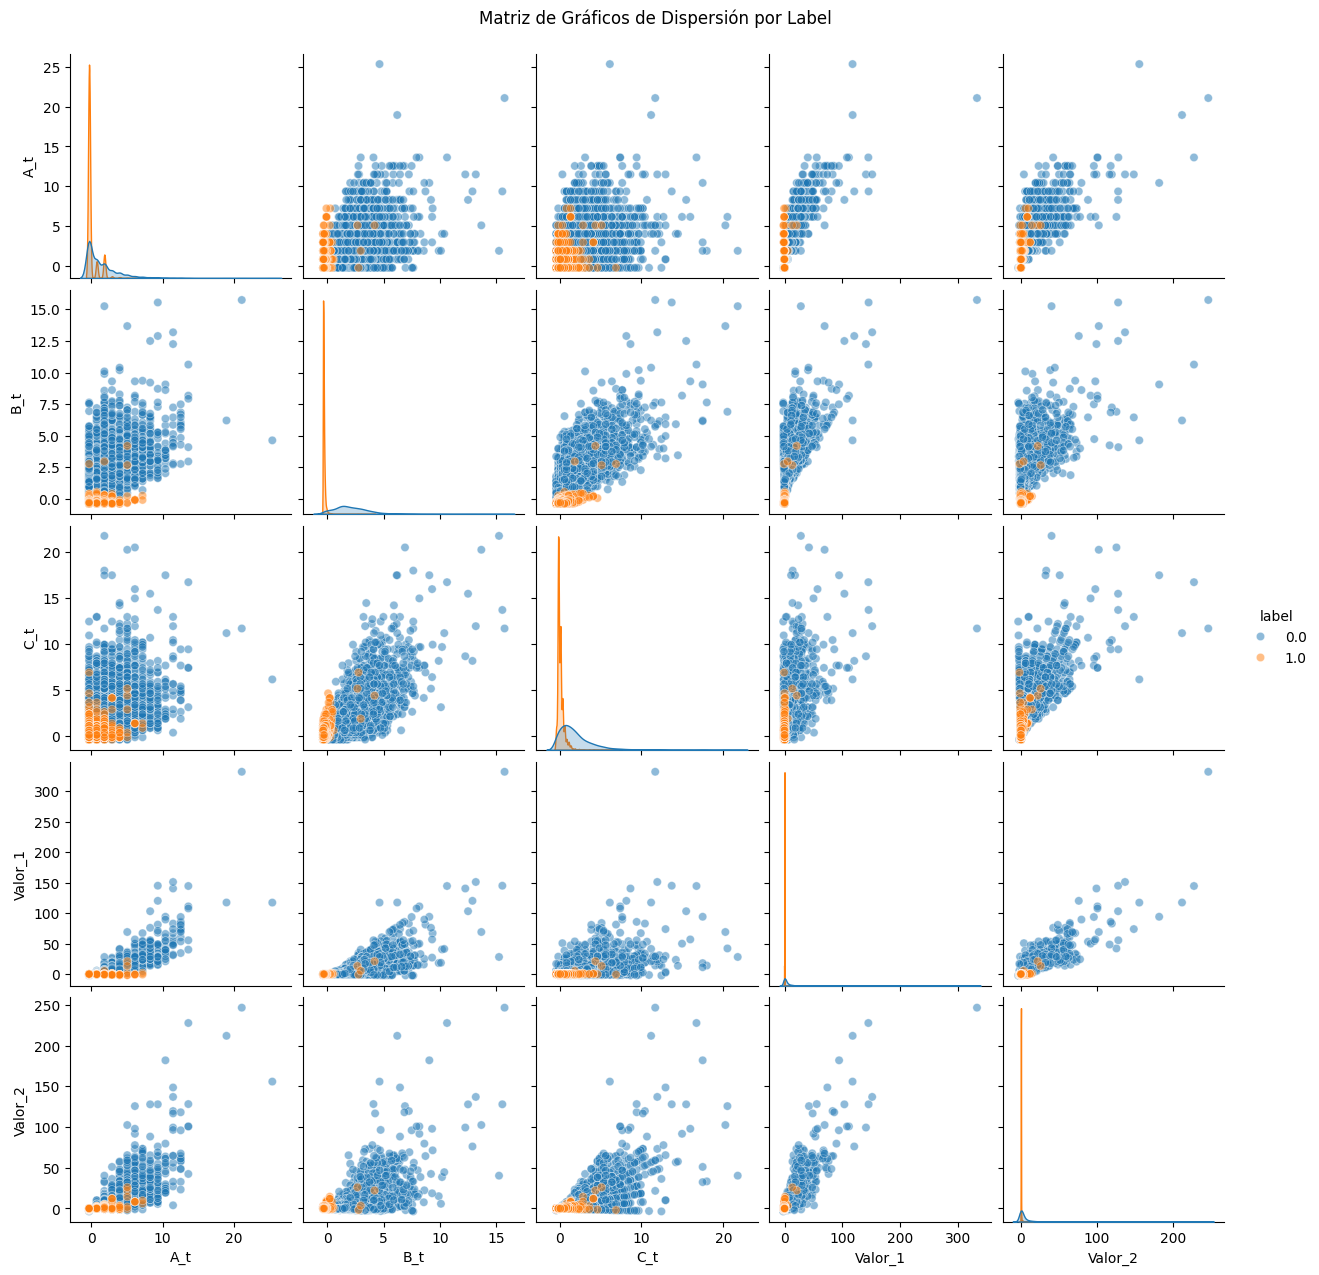

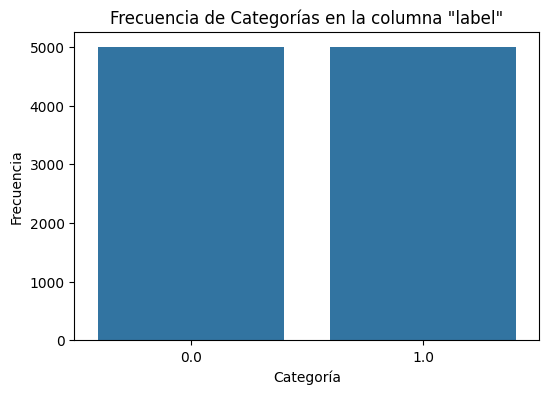

In [5]:
# Crear una matriz de gráficos de dispersión (pairplot)

columnas_seleccionadas = ['A_t', 'B_t', 'C_t', 'Valor_1', 'Valor_2', 'label']

# Crear la matriz de gráficos de dispersión (pairplot)
sns.pairplot(data[columnas_seleccionadas], hue='label', plot_kws={'alpha': 0.5})
plt.suptitle('Matriz de Gráficos de Dispersión por Label', y=1.02)
plt.show()

# Crear un gráfico de barras de la frecuencia de las categorías
frecuencia_categorias = data['label'].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=frecuencia_categorias.index.astype(str), y=frecuencia_categorias.values)
plt.title('Frecuencia de Categorías en la columna "label"')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.show()

Como se puede observar, el dataset está balanceado, con el mismo número de ejemplos para cada clase (label = 0 y label = 1). Esto es relevante porque evita sesgos durante el entrenamiento de modelos de clasificación.

En el pairplot generado, se aprecia que los datos se agrupan de forma distinta según la etiqueta asignada. Específicamente, los ejemplos con label = 1 tienden a concentrarse en valores más bajos para las variables analizadas, mientras que los de label = 0 se dispersan en valores más altos. Esto sugiere que las características numéricas extraídas reflejan diferencias reales entre los dos tipos de comentarios.

In [6]:
comentario = data.iloc[5001]['comentario']
label = data.iloc[5001]['label']

print(f"Comentario de la primera fila: {comentario}")
print(f"Label de la primera fila: {label}")

Comentario de la primera fila: cristinar,cifuent,podrio,haber,ser,presidenta,madrid,todavia,añorar,madrileño,visto,ayuso,podrio,haber,llegar,ser,presidenta,madrid,supuesto,nivel,estatal,quizas,tambien,mala,cabeza,hundio,futuro,politico,fango,imposible,regresar,necesidad,tenia,demostrar,habio,sacado,master,siquiera,casado,urdio,plan,amenaza,abuso,poder,falsificar,documento,oficial,penado,carcel,necesitar,carrera,politico,rematar,desastre,pillar,hurtar,uno,crema,facial,podrio,haber,pagar,tranquilamente,cleptomania,oculto,camar,indiscreta,destrozar,verguenza,libro,
Label de la primera fila: 1.0


Al inspeccionar manualmente un ejemplo con label = 1, observamos que el comentario contiene un lenguaje agresivo y acusatorio, con múltiples referencias negativas y términos peyorativos, lo que coincide con la interpretación de que esta clase representa comentarios de odio.

En consecuencia, podemos asumir que label = 0 corresponde a comentarios no ofensivos o neutros, mientras que label = 1 indica comentarios con contenido de odio, insultos o ataques personales.

In [7]:
# Eliminar columnas que empiecen por 'Valor_' y la columna 'comentario'
data_cleaned = data.drop(columns=[col for col in data.columns if col.startswith('Valor_') or col == 'comentario'])

# Mostrar las primeras filas del nuevo dataframe para verificar
print("\nPrimeras filas del dataframe limpio:")
print(data_cleaned.head(5))


Primeras filas del dataframe limpio:
   A   B   C  D  E  label       A_t       B_t        C_t       D_t       E_t
0  2  64  30  0  2    0.0  1.851102  2.759647   7.145831 -0.416577  0.440638
1  4  70  21  0  0    0.0  3.990202  3.054765   4.877255 -0.416577 -0.531099
2  4  88  50  0  0    0.0  3.990202  3.940120  12.187108 -0.416577 -0.531099
3  3  38  21  0  0    0.0  2.920652  1.480801   4.877255 -0.416577 -0.531099
4  0  59  17  0  0    0.0 -0.287998  2.513715   3.869000 -0.416577 -0.531099


In [8]:
# Estandarizar las columnas, excepto 'label'
features = data_cleaned.drop(columns=['label'])
labels = data_cleaned['label']

# Aplicar estandarización
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Crear nuevo DataFrame con las columnas estandarizadas
import pandas as pd
data_standardized = pd.DataFrame(features_scaled, columns=features.columns)
data_standardized['label'] = labels.values  # Añadir la columna 'label' de nuevo

# Verificar las primeras filas
print("\nPrimeras filas del dataframe estandarizado:")
print(data_standardized.head(5))



Primeras filas del dataframe estandarizado:
          A         B         C         D         E       A_t       B_t  \
0  0.598584  1.114413  3.324603 -0.258895 -0.073497  0.598584  1.114413   
1  1.746837  1.290828  2.094554 -0.258895 -0.806272  1.746837  1.290828   
2  1.746837  1.820075  6.058045 -0.258895 -0.806272  1.746837  1.820075   
3  1.172711  0.349946  2.094554 -0.258895 -0.806272  1.172711  0.349946   
4 -0.549669  0.967400  1.547866 -0.258895 -0.806272 -0.549669  0.967400   

        C_t       D_t       E_t  label  
0  3.324603 -0.258895 -0.073497    0.0  
1  2.094554 -0.258895 -0.806272    0.0  
2  6.058045 -0.258895 -0.806272    0.0  
3  2.094554 -0.258895 -0.806272    0.0  
4  1.547866 -0.258895 -0.806272    0.0  


In [9]:
# Separar las características y las etiquetas
df = data_standardized.copy()

# Eliminar columnas duplicadas: en este caso, quitamos las '_t'
columnas_a_quitar = ['A_t', 'B_t', 'C_t', 'D_t', 'E_t']
df = df.drop(columns=columnas_a_quitar)

# Separar características (X) y etiquetas (y)
X = df.drop(columns=['label'])
y = df['label']

# Verificar dimensiones
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

# Verificar primeras filas
print("\nPrimeras filas de X:")
print(X.head())

print("\nPrimeras etiquetas (y):")
print(y.head())


Dimensiones de X: (10000, 5)
Dimensiones de y: (10000,)

Primeras filas de X:
          A         B         C         D         E
0  0.598584  1.114413  3.324603 -0.258895 -0.073497
1  1.746837  1.290828  2.094554 -0.258895 -0.806272
2  1.746837  1.820075  6.058045 -0.258895 -0.806272
3  1.172711  0.349946  2.094554 -0.258895 -0.806272
4 -0.549669  0.967400  1.547866 -0.258895 -0.806272

Primeras etiquetas (y):
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: label, dtype: float64


### PCA

In [20]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Crear un DataFrame con los resultados
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['label'] = y.values  # Añadir la etiqueta para graficar

# Verificar los primeros valores
print("Primeras filas del DataFrame con PCA:")
print(pca_df.head())


Primeras filas del DataFrame con PCA:
       PCA1      PCA2  label
0  2.731745  0.181775    0.0
1  3.007871  0.090378    0.0
2  5.418864  0.520701    0.0
3  2.202662  0.001223    0.0
4  1.480875 -0.221601    0.0


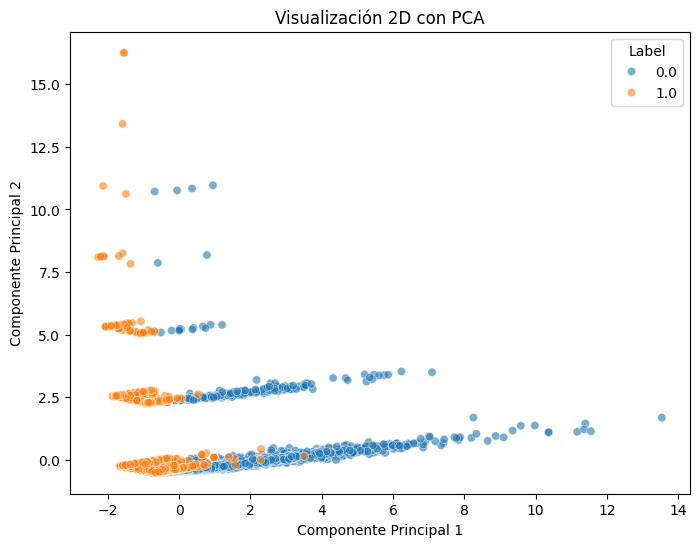

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='label', alpha=0.6)
plt.title('Visualización 2D con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Label')
plt.show()

In [18]:
# Aplicar PCA
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

# Crear un DataFrame con los resultados de PCA
pca_3d_df = pd.DataFrame(X_pca_3d, columns=['PCA1', 'PCA2', 'PCA3'])
pca_3d_df['label'] = y.values

print("Primeras filas del DataFrame con PCA 3D:")
print(pca_3d_df.head())

Primeras filas del DataFrame con PCA 3D:
       PCA1      PCA2      PCA3  label
0  2.731745  0.181775  0.958968    0.0
1  3.007871  0.090378  0.664986    0.0
2  5.418864  0.520701  1.486550    0.0
3  2.202662  0.001223  0.398834    0.0
4  1.480875 -0.221601 -0.584350    0.0


In [24]:
# Visualizar los resultados de PCA
fig = px.scatter_3d(
    pca_3d_df,
    x='PCA1', y='PCA2', z='PCA3',
    color=pca_3d_df['label'].astype(str),
    title='Visualización 3D con PCA',
    opacity=0.6
)

fig.update_traces(marker=dict(size=2))  # Puedes ajustar el número (por ejemplo, 2 o 1.5 si quieres más pequeño)

fig.show()

In [28]:
# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Entrenar un modelo de clasificación (por ejemplo, RandomForest)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predecir y evaluar el modelo
y_pred = model.predict(X_test)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print(f"\nPrecisión (accuracy): {accuracy_score(y_test, y_pred):.2f}")

Matriz de confusión:
[[978  22]
 [ 18 982]]

Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1000
         1.0       0.98      0.98      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000


Precisión (accuracy): 0.98


#### Analice los resultados obtenidos por PCA

Se aplicó PCA con el objetivo de reducir la dimensionalidad del dataset a dos y tres dimensiones para facilitar la visualización y comprensión de la estructura de los datos. Esta técnica transformó el espacio original en nuevas variables no correlacionadas (componentes principales), maximizando la varianza explicada en cada eje.

En la visualización 2D, se observa una separación parcial entre las clases 0 (comentarios no ofensivos) y 1 (comentarios de odio). Aunque hay cierta superposición, los ejemplos con label = 1 tienden a agruparse en regiones específicas del plano, especialmente hacia valores bajos de los componentes. Esto indica que los datos tienen una estructura subyacente que permite cierta diferenciación entre clases.

En la visualización 3D, esta separación es aún más evidente. La inclusión de una tercera dimensión (PCA3) permite observar mejor la dispersión y agrupamiento de los datos. Se nota que muchos puntos con label = 1 se concentran en una franja más estrecha, mientras que los de label = 0 están más dispersos, lo cual podría deberse a la mayor diversidad léxica en los comentarios no ofensivos.

Además, el modelo de clasificación Random Forest entrenado sobre los datos originales estandarizados alcanzó una precisión del 98%, lo que respalda la idea de que las variables extraídas y su proyección mediante PCA capturan información relevante para distinguir entre ambas clases.

### t-SNE

In [13]:
# Aplicar t-SNE

# Crear un DataFrame con los resultados de t-SNE

# Visualizar los resultados de t-SNE


#### Analice los resultados obtenidos por t-SNE

### Utilizar t-SNE para clasificar

In [14]:
# Dividir los datos en conjunto de entrenamiento y prueba


# Entrenar un modelo de clasificación (por ejemplo, RandomForest)

# Predecir y evaluar el modelo


#### ¿Se puede utilizar la reducción de dimensinalidad obtenida por t-SNE para entrenar un algoritmo de clasificación?

### LDA

In [15]:
# Descargar las palabras vacías en español

# Preprocesar la columna 'comentario'

# Aplicar LDA

# Mostrar los temas


Preprocesamiento: Este paso convierte el texto en una matriz de términos.
Aplicación de LDA: Ejecuta el algoritmo LDA para encontrar los temas.
Visualización de Temas: Imprime los temas encontrados con las palabras más representativas.

### LDA en función del label

In [16]:
# Descargar las palabras vacías en español


# Definir función para aplicar LDA y obtener temas

# Aplicar LDA por cada etiqueta de label y guardar en archivos CSV
    # Crear un DataFrame para los temas

    
    # Guardar el DataFrame en un archivo CSV


In [17]:
# Generar bolsas de palabras para cada tema

# Asignar temas a comentarios

# Generar bolsas de palabras para cada etiqueta

# Asignar temas a comentarios y comparar con etiquetas reales

# Comparar temas asignados con etiquetas reales
